In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.format': 'pdf',
    'savefig.bbox': 'tight',
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'legend.frameon': True,
    'legend.framealpha': 1.0,
    'legend.edgecolor': '#000000',
    'legend.fancybox': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.linewidth': 1.5,
    'axes.grid': False,
    'lines.linewidth': 2.5,
    'lines.markersize': 8,
    'patch.linewidth': 1.5,
    'patch.edgecolor': '#000000',
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'axes.edgecolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})

In [2]:
import os
import random  
from PIL import Image, ImageEnhance  
from tensorflow.keras.preprocessing.image import load_img  
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Input, Flatten, Dropout, Dense  
from tensorflow.keras.optimizers import Adam  
from tensorflow.keras.applications import VGG16  
from sklearn.utils import shuffle  

2025-11-07 01:54:51.111085: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-07 01:54:51.192158: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-07 01:54:51.840217: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-07 01:54:51.843509: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-07 01:54:53.224456: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [3]:
# Directories for training and testing data
train_dir = '/home/karan/pyKaran/BrainCancer/MRI Images/Training'
test_dir = '/home/karan/pyKaran/BrainCancer/MRI Images/Testing'

In [4]:
# Load and shuffle the train data
train_paths = []
train_labels = []
for label in os.listdir(train_dir):
    for image in os.listdir(os.path.join(train_dir, label)):
        train_paths.append(os.path.join(train_dir, label, image))
        train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

# Load the test data
test_paths = []
test_labels = []
for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

In [5]:
print(f"Training samples: {len(train_paths)}, Test samples: {len(test_paths)}")


Training samples: 5712, Test samples: 1311


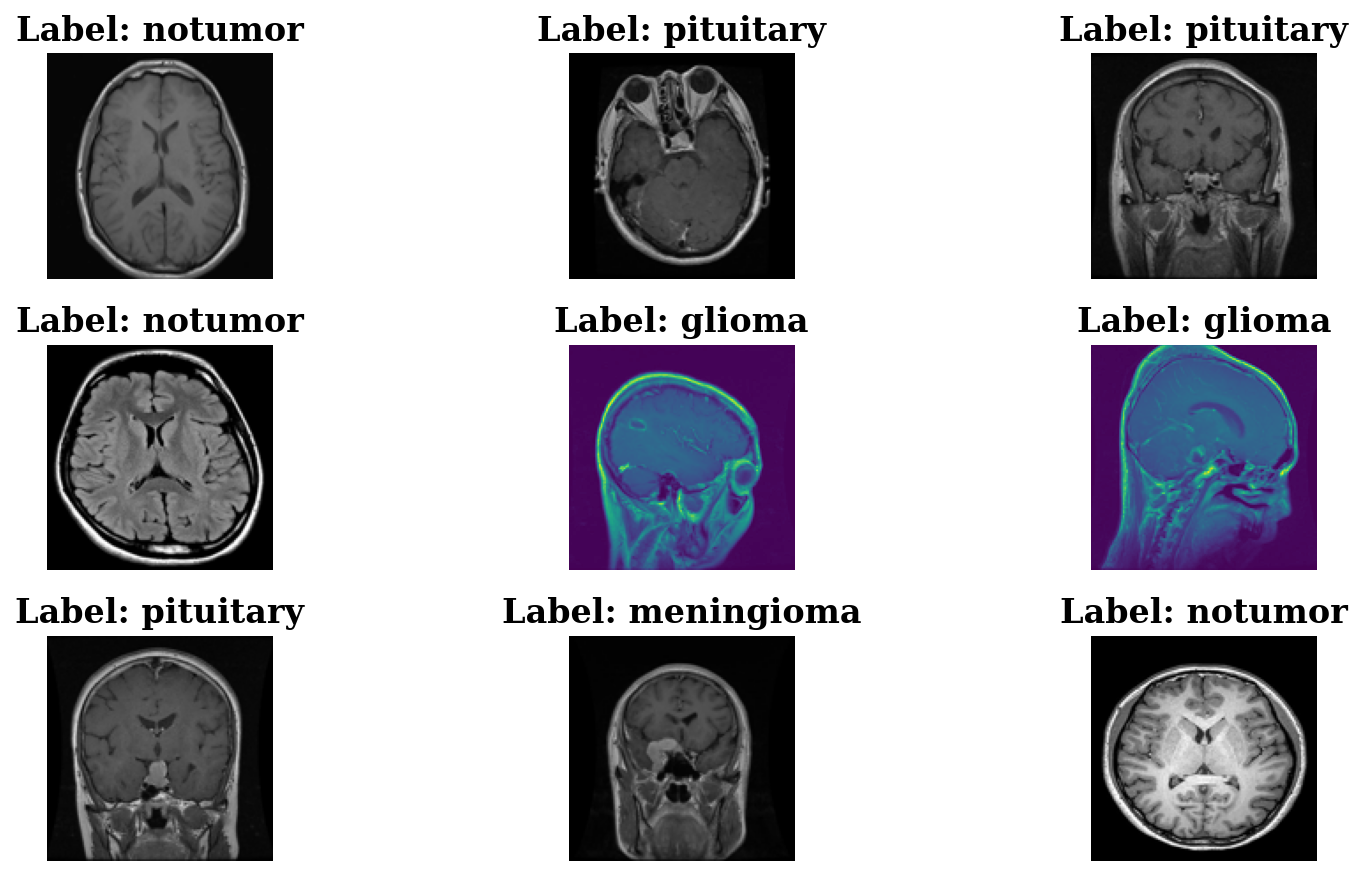

In [6]:
from PIL import Image

# Select random indices for 9 images
sample_indices = random.sample(range(len(train_paths)), 9)

plt.figure(figsize=(12, 6))

for i, sample_idx in enumerate(sample_indices):
    im = Image.open(train_paths[sample_idx]).resize((128, 128))
    
    plt.subplot(3, 3, i+1)   
    plt.imshow(im)  
    plt.axis("off")
    plt.title(f"Label: {train_labels[sample_idx]}")  

plt.tight_layout()
plt.show()


In [7]:
base_dir = "/home/karan/pyKaran/BrainCancer/MRI Images"

def get_class_counts(split):
    split_dir = os.path.join(base_dir, split)
    class_counts = {}
    for cls in os.listdir(split_dir):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            class_counts[cls] = len(os.listdir(cls_path))
    return class_counts

# Training counts
train_counts = get_class_counts("Training")

# Testing counts
test_counts = get_class_counts("Testing")

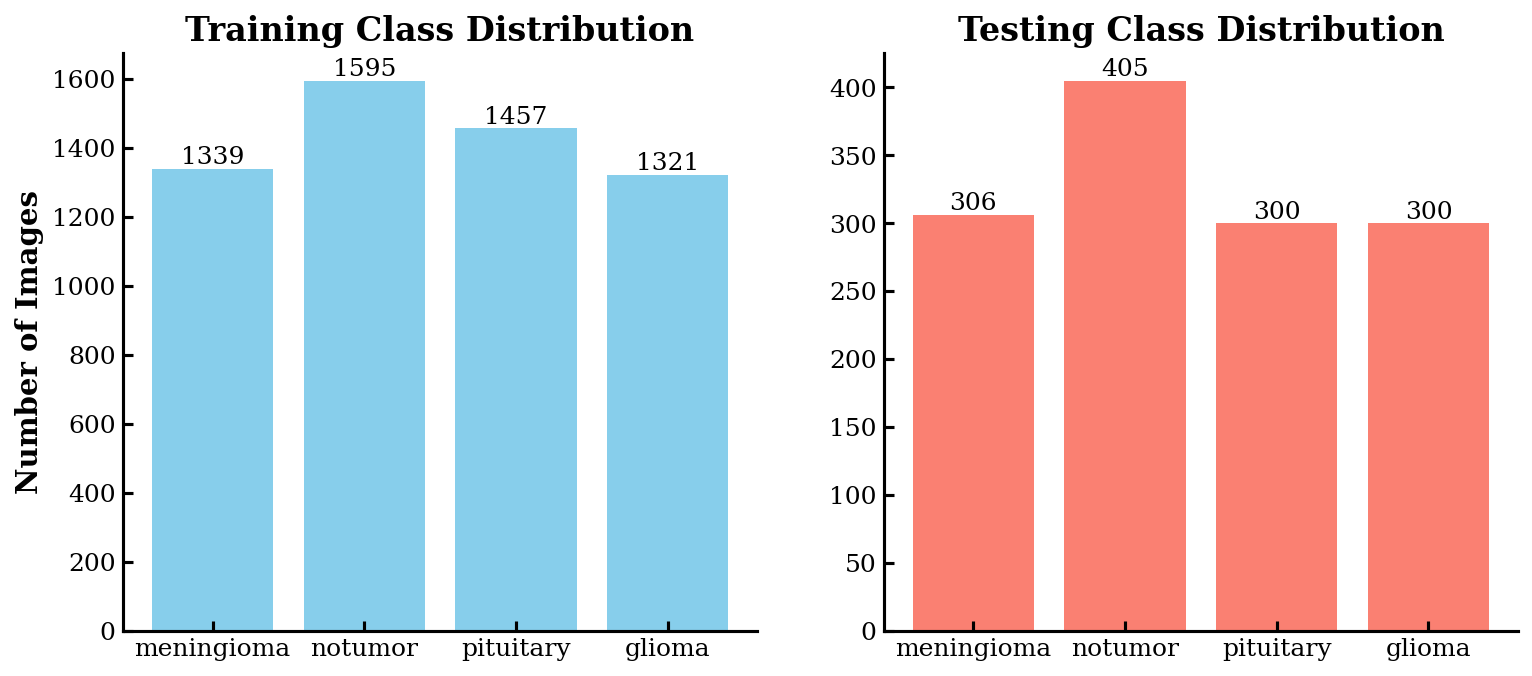

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training plot
bars1 = axes[0].bar(train_counts.keys(), train_counts.values(), color="skyblue")
axes[0].set_title("Training Class Distribution")
axes[0].set_ylabel("Number of Images")
axes[0].bar_label(bars1)   

# Testing plot
bars2 = axes[1].bar(test_counts.keys(), test_counts.values(), color="salmon")
axes[1].set_title("Testing Class Distribution")
axes[1].bar_label(bars2)   

plt.show()

In [9]:
# Image Augmentation function
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))  # Random brightness
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))  # Random contrast
    image = np.array(image) / 255.0  # Normalize pixel values to [0, 1]
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoding labels (convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir)  
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels

In [10]:
IMAGE_SIZE = 224 
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), 
    include_top=False, 
    weights='imagenet')

base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

base_model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [11]:
for i, layer in enumerate(base_model.layers):
    print(f"Layer {i}: {layer.name}, Trainable: {layer.trainable}")

Layer 0: input_1, Trainable: False
Layer 1: block1_conv1, Trainable: False
Layer 2: block1_conv2, Trainable: False
Layer 3: block1_pool, Trainable: False
Layer 4: block2_conv1, Trainable: False
Layer 5: block2_conv2, Trainable: False
Layer 6: block2_pool, Trainable: False
Layer 7: block3_conv1, Trainable: False
Layer 8: block3_conv2, Trainable: False
Layer 9: block3_conv3, Trainable: False
Layer 10: block3_pool, Trainable: False
Layer 11: block4_conv1, Trainable: False
Layer 12: block4_conv2, Trainable: False
Layer 13: block4_conv3, Trainable: False
Layer 14: block4_pool, Trainable: False
Layer 15: block5_conv1, Trainable: True
Layer 16: block5_conv2, Trainable: True
Layer 17: block5_conv3, Trainable: True
Layer 18: block5_pool, Trainable: True


In [12]:
# Build the transfer model
from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(len(os.listdir(train_dir)), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout_1 (Dropout)         (None, 256)               0

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

batch_size = 32
train_steps = len(train_paths) // batch_size
val_steps = len(test_paths) // batch_size
epochs = 25

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7)

history = model.fit(
    datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs,
    steps_per_epoch=train_steps,
    validation_data=datagen(test_paths, test_labels, batch_size=batch_size, epochs=epochs),
    validation_steps=val_steps,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
178/178 [==============================] - 669s 4s/step - loss: 0.8220 - accuracy: 0.6856 - val_loss: 0.5723 - val_accuracy: 0.7805 - lr: 1.0000e-04
Epoch 2/25
178/178 [==============================] - 756s 4s/step - loss: 0.3645 - accuracy: 0.8708 - val_loss: 0.5237 - val_accuracy: 0.8108 - lr: 1.0000e-04
Epoch 3/25
178/178 [==============================] - 719s 4s/step - loss: 0.2353 - accuracy: 0.9150 - val_loss: 0.2883 - val_accuracy: 0.8960 - lr: 1.0000e-04
Epoch 4/25
178/178 [==============================] - 675s 4s/step - loss: 0.1677 - accuracy: 0.9442 - val_loss: 0.2049 - val_accuracy: 0.9281 - lr: 1.0000e-04
Epoch 5/25
178/178 [==============================] - 697s 4s/step - loss: 0.1069 - accuracy: 0.9641 - val_loss: 0.1647 - val_accuracy: 0.9429 - lr: 1.0000e-04
Epoch 6/25
178/178 [==============================] - 724s 4s/step - loss: 0.0681 - accuracy: 0.9785 - val_loss: 0.1088 - val_accuracy: 0.9593 - lr: 1.0000e-04
Epoch 7/25
178/178 [====================

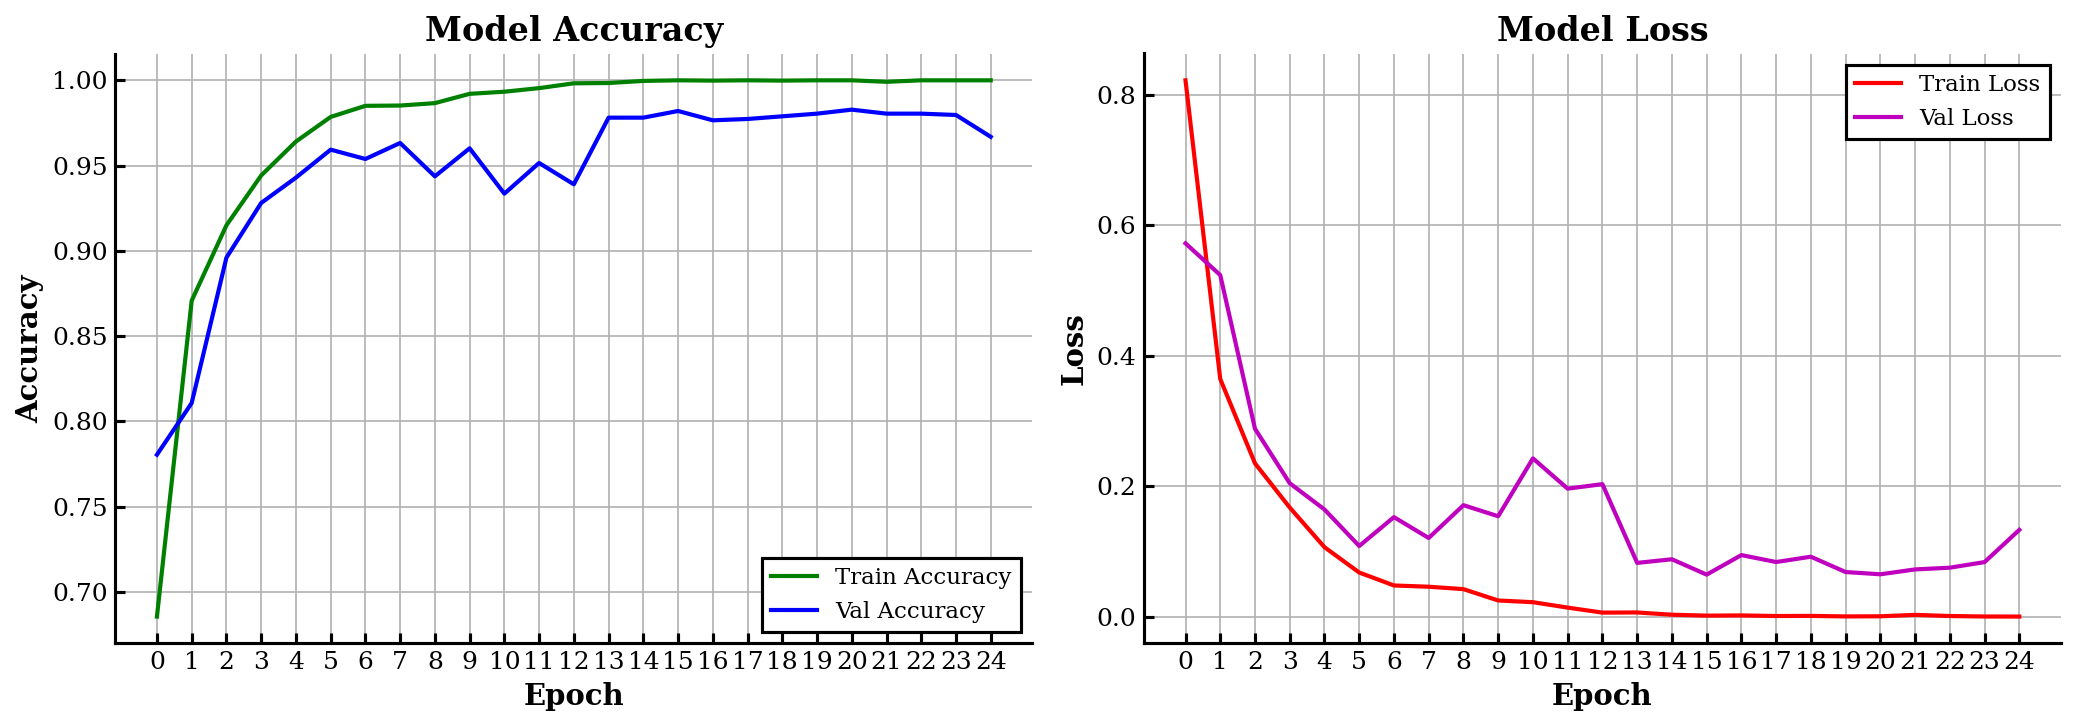

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'g-', linewidth=2, label='Train Accuracy')
plt.plot(history.history['val_accuracy'], 'b-', linewidth=2, label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(epochs))
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'r-', linewidth=2, label='Train Loss')
plt.plot(history.history['val_loss'], 'm-', linewidth=2, label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(epochs))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))


41/41 [==============================] - 88s 2s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       306
           1       1.00      1.00      1.00       405
           2       0.98      1.00      0.99       300
           3       0.99      0.94      0.97       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



Confusion Matrix:
[[297   1   6   2]
 [  0 405   0   0]
 [  0   0 300   0]
 [ 16   0   1 283]]


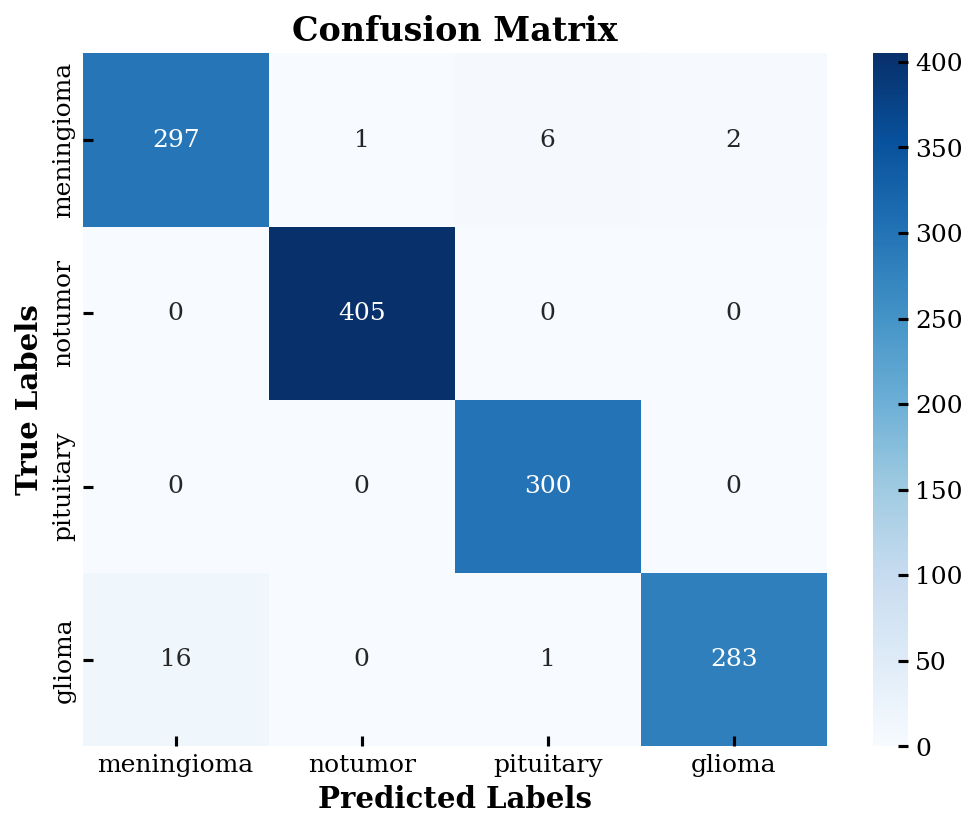

In [16]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

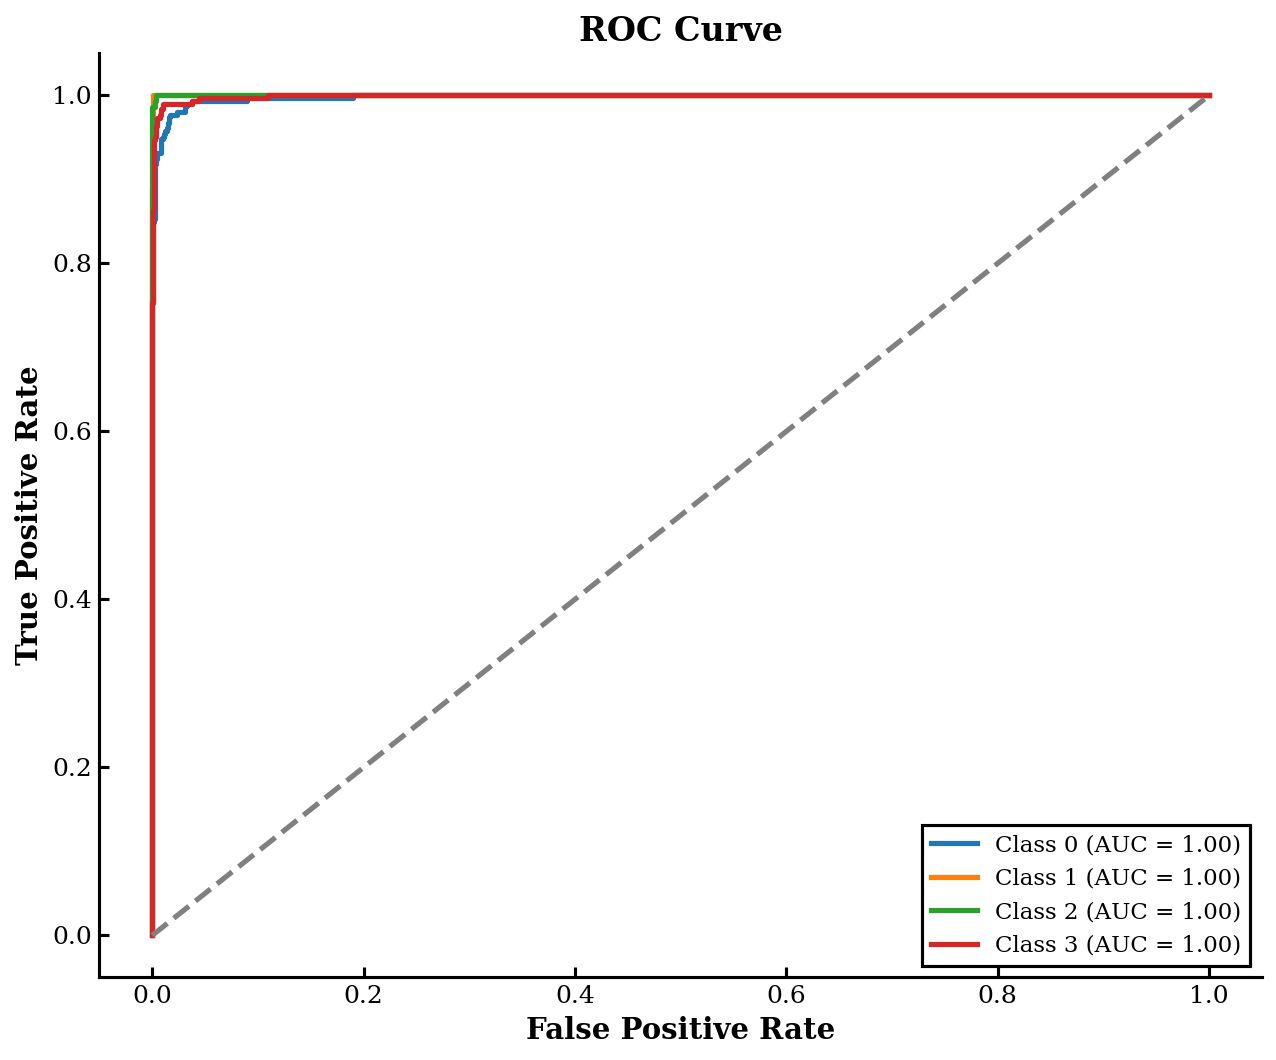

In [17]:
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model

# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()